# Data Analysis: E-Commerce Public Dataset

## Business Understanding

- When is the peak time with the highest order volume based on hour and day throughout 2017-2018?
- What is the distribution or average payment value for each payment method used by customers throughout 2017-2018?

In [2]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\LENOVO\.conda\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Wrangling

### Gathering Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

100%|██████████| 42.6M/42.6M [00:03<00:00, 11.5MB/s]

Extracting files...


Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [4]:
os.listdir(path)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

**Insight:**
- The dataset used is a Brazilian e-commerce dataset consisting of 9 CSV files containing information on customers, sellers, orders, products, and locations.

### Assessing Data

In [5]:
for csv in os.listdir(path):
    df = pd.read_csv(os.path.join(path, csv))
    print("-----------------------------------------------------------------------")
    print(f"File Info {csv}:")
    df.info()

    print(f"Head file {csv}:")
    print(df.head())

    print(f"Unique file {csv}:")
    print(df.nunique())

    print(f"Null in file {csv}:")
    print(df.isnull().sum())

    print(f"Duplicate in file {csv}:")
    print(df.duplicated().sum())
    print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
File Info olist_customers_dataset.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Head file olist_customers_dataset.csv:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529

**Insight:**
- `olist_order_reviews_dataset.csv` has null values in the `review_comment_title` column (87,656) and `review_comment_message` column (58,247), with no duplicates found.
- `olist_products_dataset.csv` has 610 null values in the `product_category_name`, `product_name_lenght`, `product_description_lenght`, and `product_photos_qty` columns, and 2 null values in `product_weight_g`, `product_length_cm`, `product_height_cm`, and `product_width_cm`, with no duplicates found.
- `olist_orders_dataset.csv` has 160 null values in `order_approved_at`, 1,783 in `order_delivered_carrier_date`, and 2,965 in `order_delivered_customer_date`, with no duplicates found.
- All other files have no null values or duplicates.


### Cleaning Data

In [6]:
output_path = "dataset"
os.makedirs(output_path, exist_ok=True)

for csv in os.listdir(path):
    if not csv.endswith('.csv'):
        continue

    filepath = os.path.join(path, csv)
    df = pd.read_csv(filepath)

    if csv == "olist_order_reviews_dataset.csv":
        df = df.drop(columns=["review_comment_title", "review_comment_message"])
        df = df.dropna()

    elif csv == "olist_orders_dataset.csv":
        df = df.dropna(subset=["order_id", "customer_id", "order_status",
                                "order_purchase_timestamp", "order_estimated_delivery_date"])

    else:
        df = df.dropna()

    df = df.drop_duplicates()
    df.to_csv(os.path.join(output_path, csv), index=False)

orders      = pd.read_csv(f"{output_path}/olist_orders_dataset.csv")
customers   = pd.read_csv(f"{output_path}/olist_customers_dataset.csv")
order_items = pd.read_csv(f"{output_path}/olist_order_items_dataset.csv")
order_pays  = pd.read_csv(f"{output_path}/olist_order_payments_dataset.csv")
order_revs  = pd.read_csv(f"{output_path}/olist_order_reviews_dataset.csv")
products    = pd.read_csv(f"{output_path}/olist_products_dataset.csv")
sellers     = pd.read_csv(f"{output_path}/olist_sellers_dataset.csv")
translation = pd.read_csv(f"{output_path}/product_category_name_translation.csv")
geolocation = pd.read_csv(f"{output_path}/olist_geolocation_dataset.csv")

valid_customer_ids = customers["customer_id"]
orders = orders[orders["customer_id"].isin(valid_customer_ids)]

valid_order_ids = orders["order_id"]
order_items = order_items[order_items["order_id"].isin(valid_order_ids)]
order_pays  = order_pays[order_pays["order_id"].isin(valid_order_ids)]
order_revs  = order_revs[order_revs["order_id"].isin(valid_order_ids)]

valid_seller_ids  = sellers["seller_id"]
valid_product_ids = products["product_id"]
order_items = order_items[order_items["seller_id"].isin(valid_seller_ids)]
order_items = order_items[order_items["product_id"].isin(valid_product_ids)]

valid_categories = translation["product_category_name"]
products = products[products["product_category_name"].isin(valid_categories)]

orders.to_csv(f"{output_path}/olist_orders_dataset.csv", index=False)
customers.to_csv(f"{output_path}/olist_customers_dataset.csv", index=False)
order_items.to_csv(f"{output_path}/olist_order_items_dataset.csv", index=False)
order_pays.to_csv(f"{output_path}/olist_order_payments_dataset.csv", index=False)
order_revs.to_csv(f"{output_path}/olist_order_reviews_dataset.csv", index=False)
products.to_csv(f"{output_path}/olist_products_dataset.csv", index=False)
sellers.to_csv(f"{output_path}/olist_sellers_dataset.csv", index=False)
translation.to_csv(f"{output_path}/product_category_name_translation.csv", index=False)
geolocation.to_csv(f"{output_path}/olist_geolocation_dataset.csv", index=False)

print(f"orders: {len(orders)}")
print(f"customers: {len(customers)}")
print(f"order_items: {len(order_items)}")
print(f"order_payments: {len(order_pays)}")
print(f"order_reviews: {len(order_revs)}")
print(f"products: {len(products)}")
print(f"sellers: {len(sellers)}")

orders: 99441
customers: 99441
order_items: 111046
order_payments: 103886
order_reviews: 99224
products: 32327
sellers: 3095


In [7]:
for csv in os.listdir(path):
    df = pd.read_csv(os.path.join(output_path, csv))
    print("-----------------------------------------------------------------------")
    print(f"File Information {csv}:")
    df.info()

    print(f"Head file {csv}:")
    print(df.head())

    print(f"Null in file {csv}:")
    print(df.isnull().sum())

    print(f"Duplicate in file {csv}:")
    print(df.duplicated().sum())
    print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
File Information olist_customers_dataset.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Head file olist_customers_dataset.csv:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5

**Insight:**
- No null values or duplicates remain in the available dataset, and all files have been aligned with each other to ensure no missing data.

## Exploratory Data Analysis (EDA)

### Distribution Explore

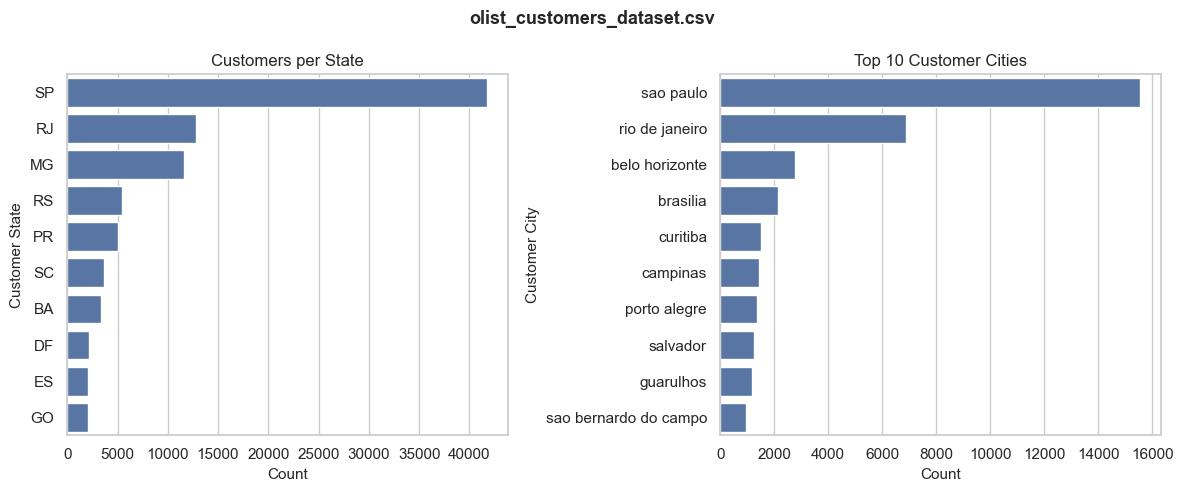

Saved: olist_customers_dataset_eda.png


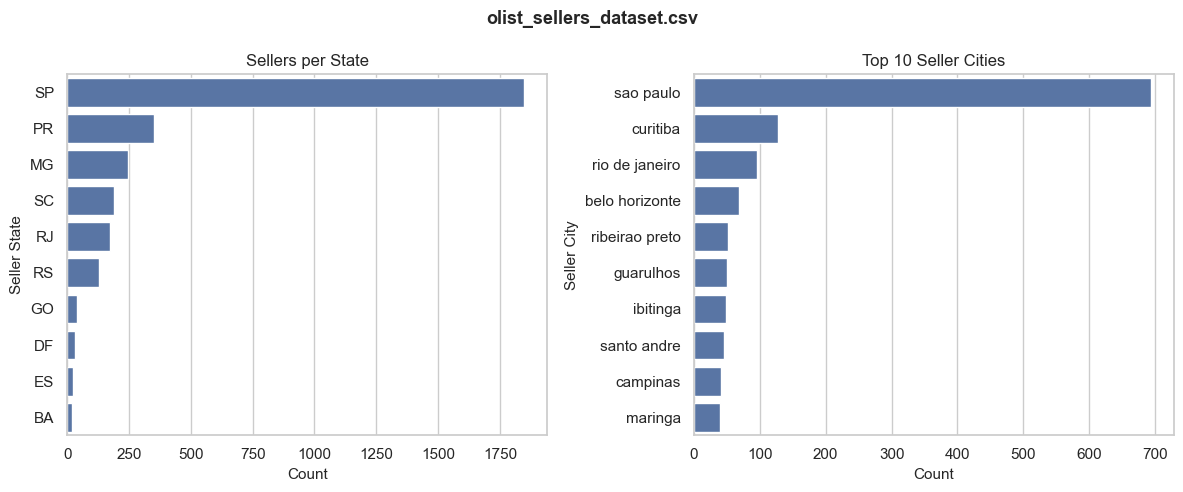

Saved: olist_sellers_dataset_eda.png


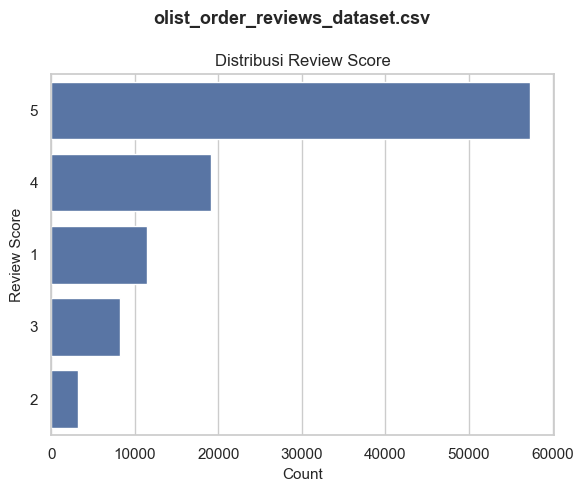

Saved: olist_order_reviews_dataset_eda.png


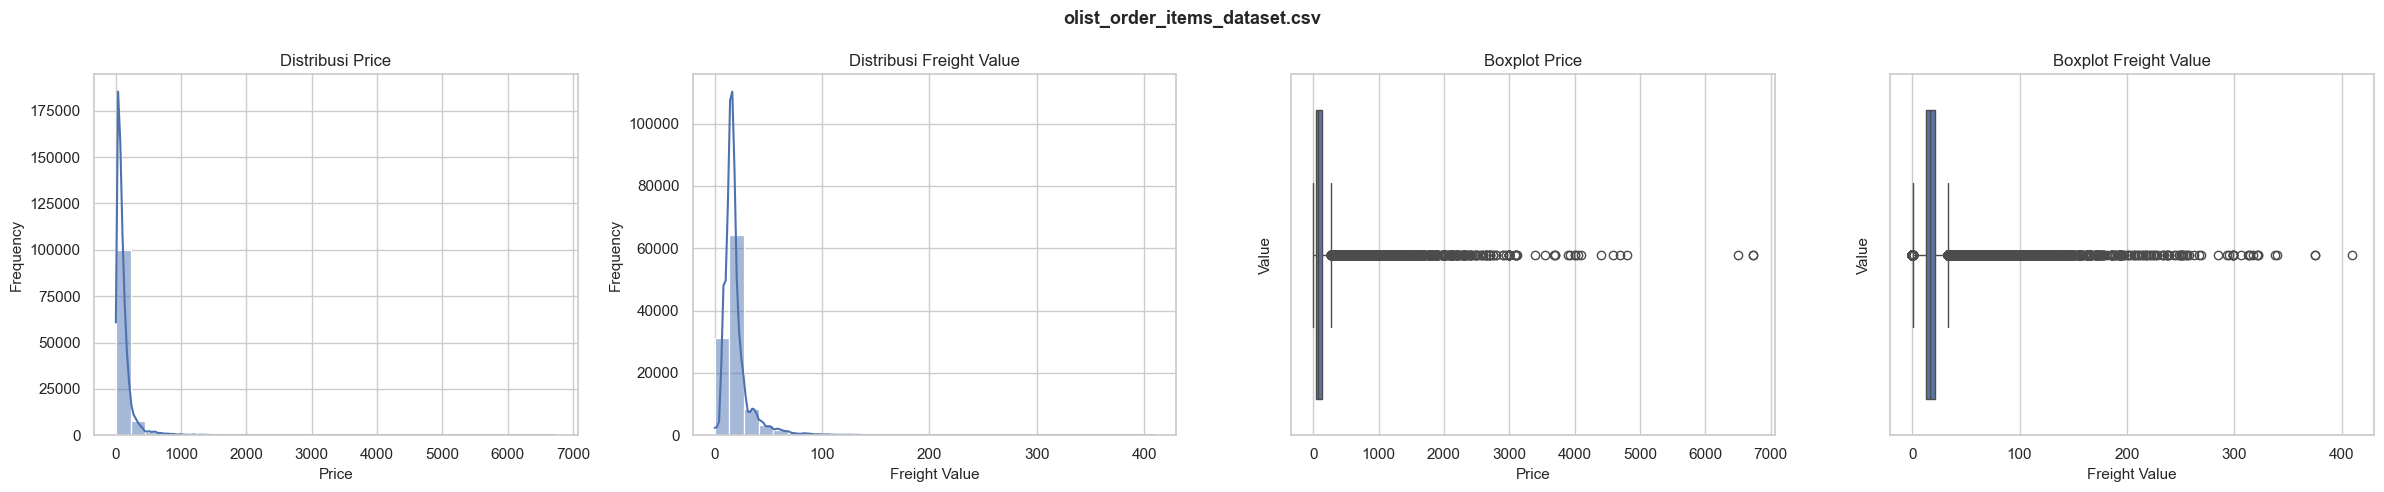

Saved: olist_order_items_dataset_eda.png


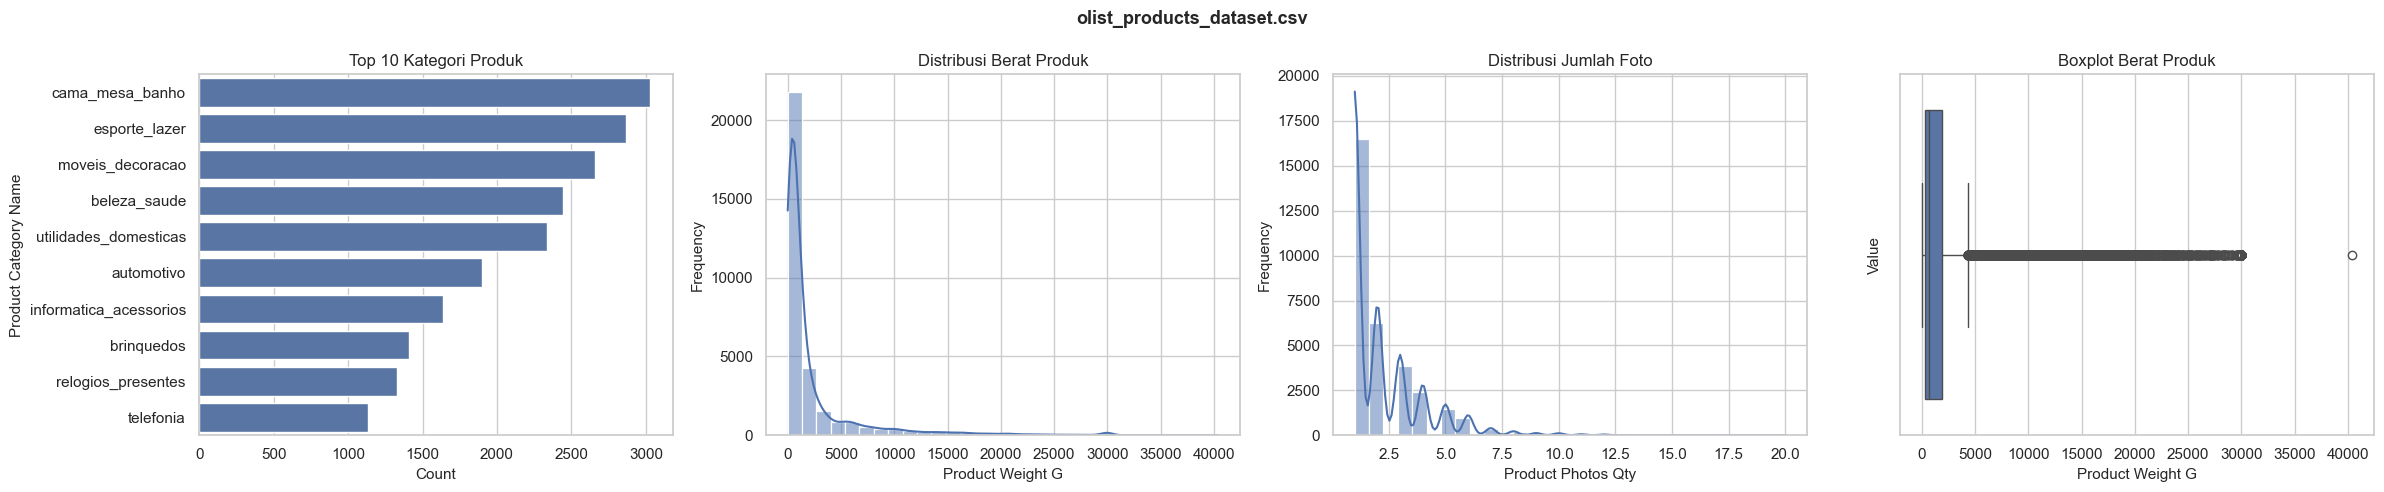

Saved: olist_products_dataset_eda.png


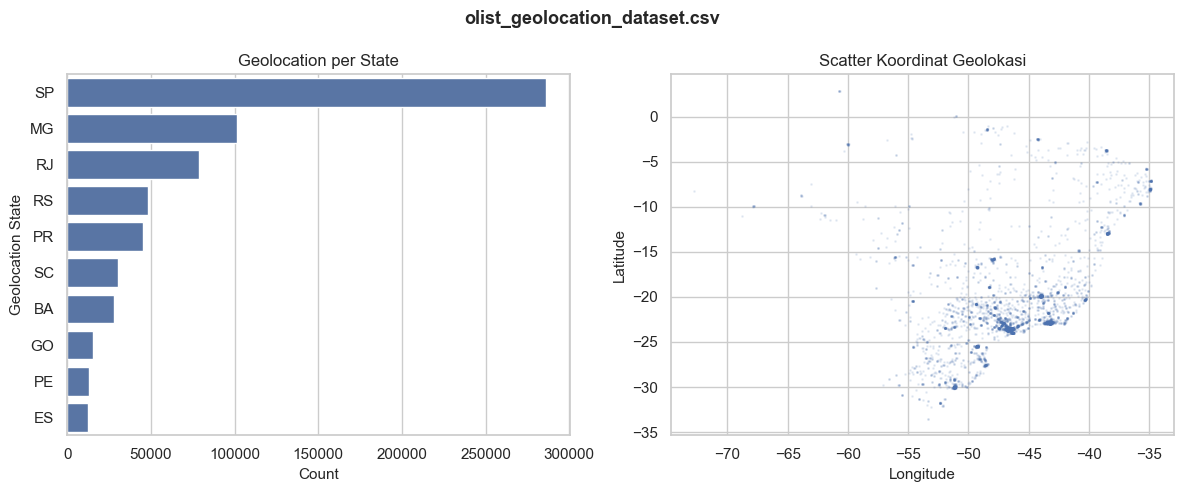

Saved: olist_geolocation_dataset_eda.png


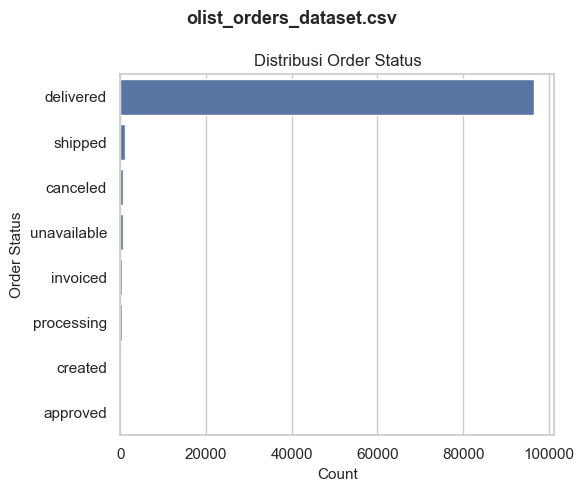

Saved: olist_orders_dataset_eda.png


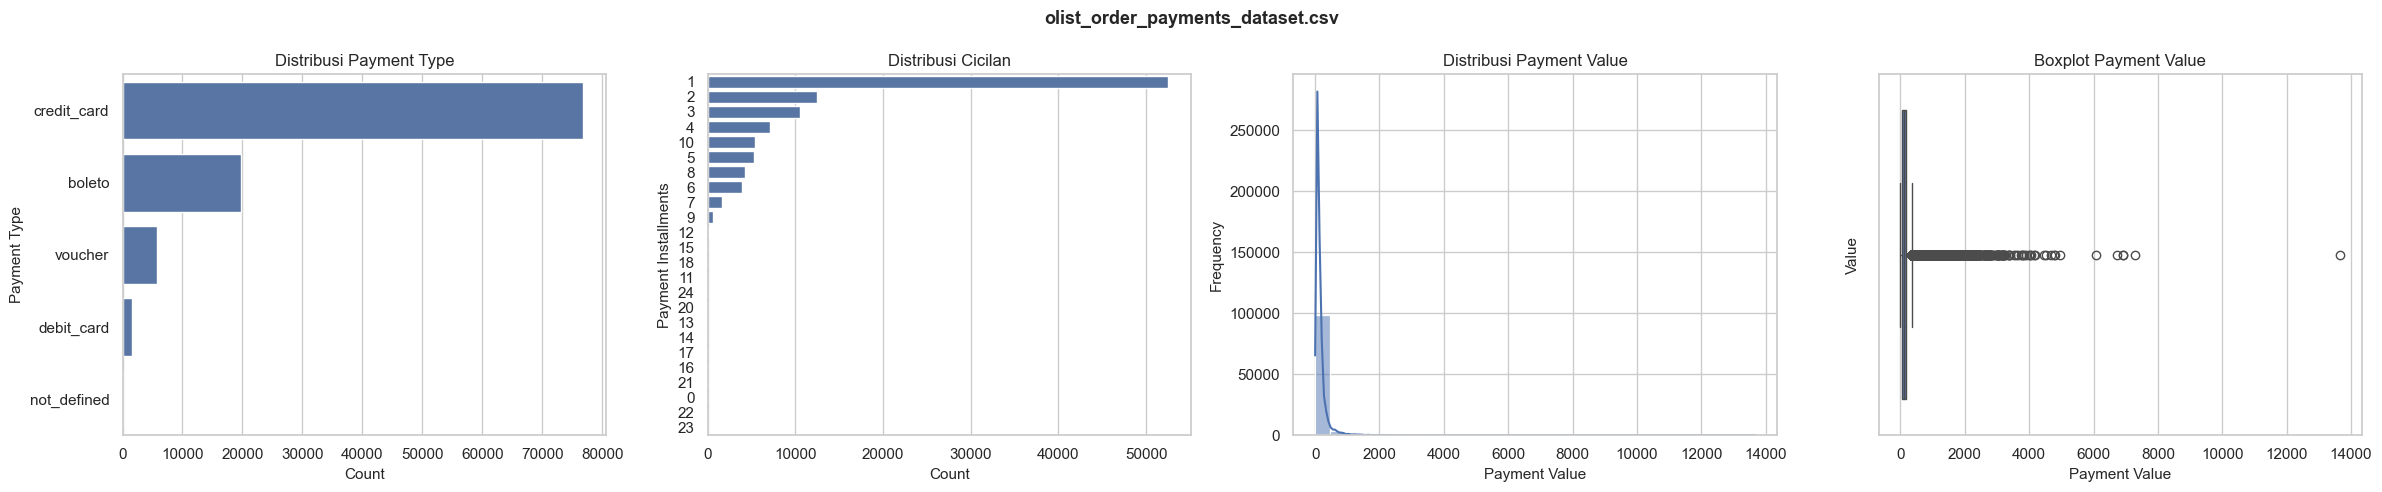

Saved: olist_order_payments_dataset_eda.png


In [8]:
sns.set_theme(style="whitegrid")

configs = {
    "olist_customers_dataset.csv": [
        {"type": "countplot", "col": "customer_state", "title": "Customers per State", "top": 10},
        {"type": "countplot", "col": "customer_city", "title": "Top 10 Customer Cities", "top": 10},
    ],
    "olist_sellers_dataset.csv": [
        {"type": "countplot", "col": "seller_state", "title": "Sellers per State", "top": 10},
        {"type": "countplot", "col": "seller_city", "title": "Top 10 Seller Cities", "top": 10},
    ],
    "olist_order_reviews_dataset.csv": [
        {"type": "countplot", "col": "review_score", "title": "Distribusi Review Score"},
    ],
    "olist_order_items_dataset.csv": [
        {"type": "hist", "col": "price", "title": "Distribusi Price"},
        {"type": "hist", "col": "freight_value", "title": "Distribusi Freight Value"},
        {"type": "box", "col": "price", "title": "Boxplot Price"},
        {"type": "box", "col": "freight_value", "title": "Boxplot Freight Value"},
    ],
    "olist_products_dataset.csv": [
        {"type": "countplot", "col": "product_category_name", "title": "Top 10 Kategori Produk", "top": 10},
        {"type": "hist", "col": "product_weight_g", "title": "Distribusi Berat Produk"},
        {"type": "hist", "col": "product_photos_qty", "title": "Distribusi Jumlah Foto"},
        {"type": "box", "col": "product_weight_g", "title": "Boxplot Berat Produk"},
    ],
    "olist_geolocation_dataset.csv": [
        {"type": "countplot", "col": "geolocation_state", "title": "Geolocation per State", "top": 10},
        {"type": "scatter", "col_x": "geolocation_lng", "col_y": "geolocation_lat", "title": "Scatter Koordinat Geolokasi", "sample": 5000},
    ],
    "olist_orders_dataset.csv": [
        {"type": "countplot", "col": "order_status", "title": "Distribusi Order Status"},
    ],
    "olist_order_payments_dataset.csv": [
        {"type": "countplot", "col": "payment_type", "title": "Distribusi Payment Type"},
        {"type": "countplot", "col": "payment_installments", "title": "Distribusi Cicilan"},
        {"type": "hist", "col": "payment_value", "title": "Distribusi Payment Value"},
        {"type": "box", "col": "payment_value", "title": "Boxplot Payment Value"},
    ],
}

for filename, charts in configs.items():
    filepath = os.path.join(output_path, filename)
    if not os.path.exists(filepath):
        continue

    df = pd.read_csv(filepath)
    n = len(charts)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    fig.suptitle(filename, fontsize=13, fontweight="bold")

    for ax, chart in zip(axes, charts):
        ctype = chart["type"]

        if ctype == "countplot":
            col = chart["col"]
            top = chart.get("top")
            if top:
                order = df[col].value_counts().iloc[:top].index
            else:
                order = df[col].value_counts().index
            sns.countplot(data=df, y=col, order=order, ax=ax)
            ax.set_title(chart["title"])
            ax.set_xlabel("Count", fontsize=11)
            ax.set_ylabel(col.replace("_", " ").title(), fontsize=11)

        elif ctype == "hist":
            col = chart["col"]
            sns.histplot(df[col], bins=30, kde=True, ax=ax)
            ax.set_title(chart["title"])
            ax.set_xlabel(col.replace("_", " ").title(), fontsize=11)
            ax.set_ylabel("Frequency", fontsize=11)

        elif ctype == "box":
            col = chart["col"]
            sns.boxplot(x=df[col], ax=ax)
            ax.set_title(chart["title"])
            ax.set_xlabel(col.replace("_", " ").title(), fontsize=11)
            ax.set_ylabel("Value", fontsize=11)

        elif ctype == "scatter":
            sample = chart.get("sample", len(df))
            dfs = df.sample(min(sample, len(df)), random_state=42)
            ax.scatter(dfs[chart["col_x"]], dfs[chart["col_y"]], alpha=0.1, s=1)
            ax.set_title(chart["title"])
            ax.set_xlabel("Longitude", fontsize=11)
            ax.set_ylabel("Latitude", fontsize=11)

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, filename.replace(".csv", "_eda.png")), dpi=100)
    plt.show()
    print(f"Saved: {filename.replace('.csv', '_eda.png')}")

**Insight:**

**Customers & Sellers**
- Customers and sellers are concentrated in São Paulo (SP), far surpassing other states, indicating the dominance of e-commerce economic activity in southeastern Brazil.
- Top customer cities: São Paulo, Rio de Janeiro, and Belo Horizonte — consistent with Brazil's major population centers.
- Sellers are also dominated by SP, followed by PR and MG, reflecting a centralized supply chain.

**Review Score**
- Review scores are dominated by 5-star ratings, followed by 4-star, indicating generally high customer satisfaction.
- Score 1 appears more frequently than scores 2 and 3, a common pattern on rating platforms where dissatisfied customers tend to give extreme ratings.

**Price & Freight**
- Price distribution is highly right-skewed, with the majority of products priced below 1,000, and extreme outliers reaching up to 7,000.
- Freight value is also right-skewed, with most values below 50 and outliers reaching up to 400.
- Boxplots for both variables show a significant number of outliers.

**Products**
- Top categories: `cama_mesa_banho` (home essentials), `esporte_lazer`, and `moveis_decoracao`.
- Product weight is mostly below 5,000 grams, with a right-skewed distribution and outliers reaching up to 40,000 grams.
- Most products have 1–3 photos.

**Order Status**
- Nearly all orders have a `delivered` status, as the dataset is historical.
- Other statuses (shipped, canceled, unavailable) represent a very small proportion.

**Payment**
- Credit card dominates by a large margin, followed by boleto, while debit card usage is minimal.
- The most common installment plan is 1x (full payment), followed by 2–10 installments.
- Payment value is right-skewed, with most transactions below 500 and outliers reaching up to 14,000.
- A `not_defined` category exists within the payment type field.

## Visualization & Explanatory Analysis

### Business Understanding 1:

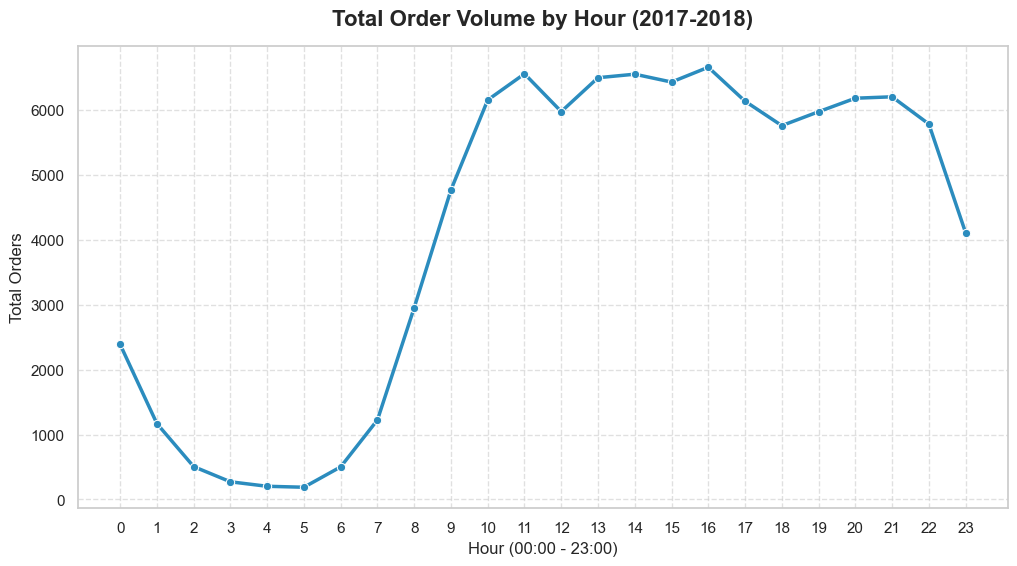

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11868\156184414.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_filtered.groupby(['order_day', 'order_hour'])['order_id'].count().unstack()


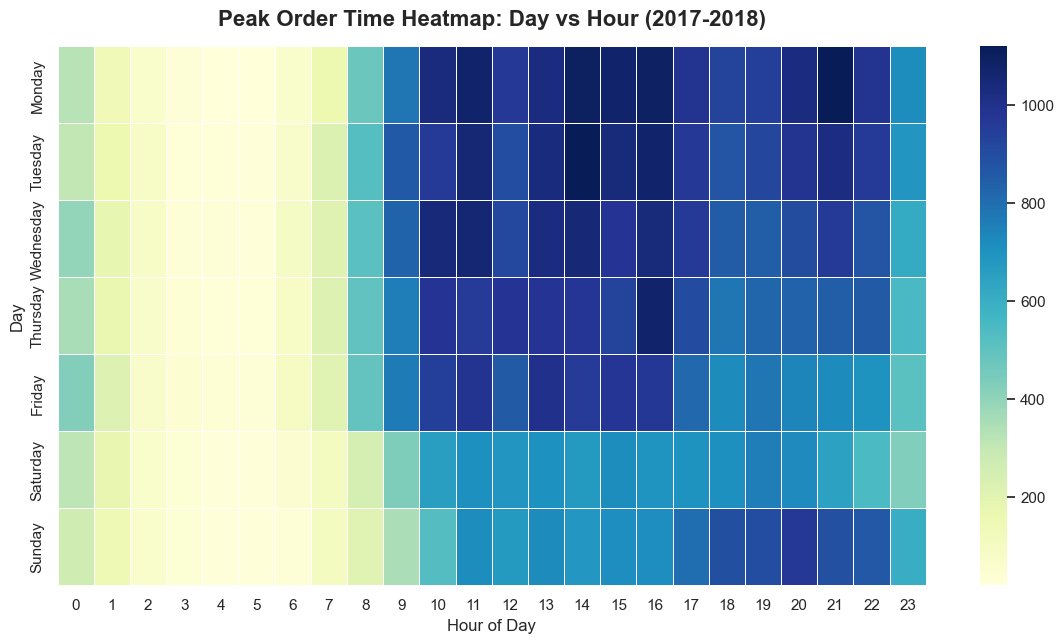

In [9]:
path_orders = f"dataset/olist_orders_dataset.csv"
df_orders = pd.read_csv(path_orders)

df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

df_filtered = df_orders[df_orders['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()

df_filtered['order_hour'] = df_filtered['order_purchase_timestamp'].dt.hour
df_filtered['order_day'] = df_filtered['order_purchase_timestamp'].dt.day_name()

urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_filtered['order_day'] = pd.Categorical(df_filtered['order_day'], categories=urutan_hari, ordered=True)

plt.figure(figsize=(12, 6))
volume_per_hour = df_filtered.groupby('order_hour')['order_id'].count()

sns.lineplot(x=volume_per_hour.index, y=volume_per_hour.values, marker='o', color='#2b8cbe', linewidth=2.5)
plt.title('Total Order Volume by Hour (2017-2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour (00:00 - 23:00)', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(14, 7))
heatmap_data = df_filtered.groupby(['order_day', 'order_hour'])['order_id'].count().unstack()

heatmap_data.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, linewidths=.5)
plt.title('Peak Order Time Heatmap: Day vs Hour (2017-2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day', fontsize=12)
plt.show()

### Business Understanding 2:

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11868\1608931120.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filtered, x='payment_type', y='payment_value', estimator='mean', errorbar=None, palette='viridis')


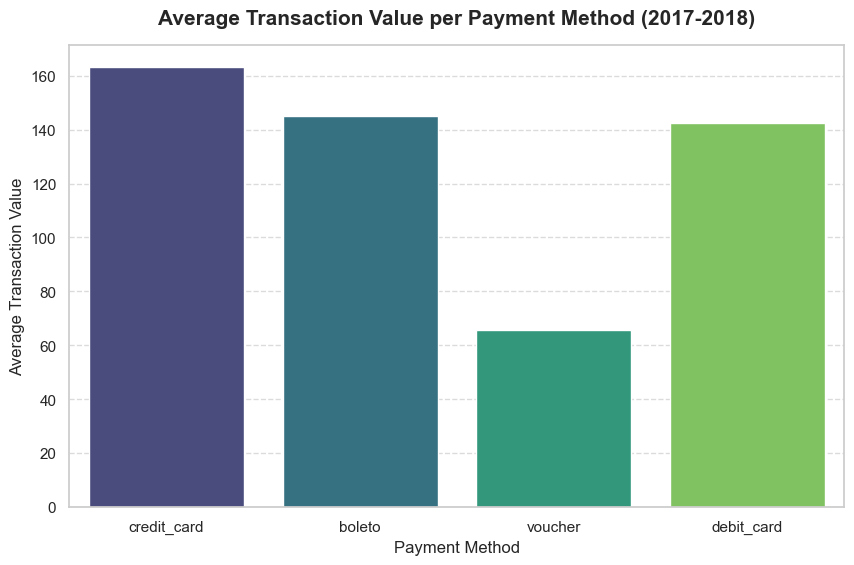

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11868\1608931120.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='payment_type', y='payment_value', palette='Set2')


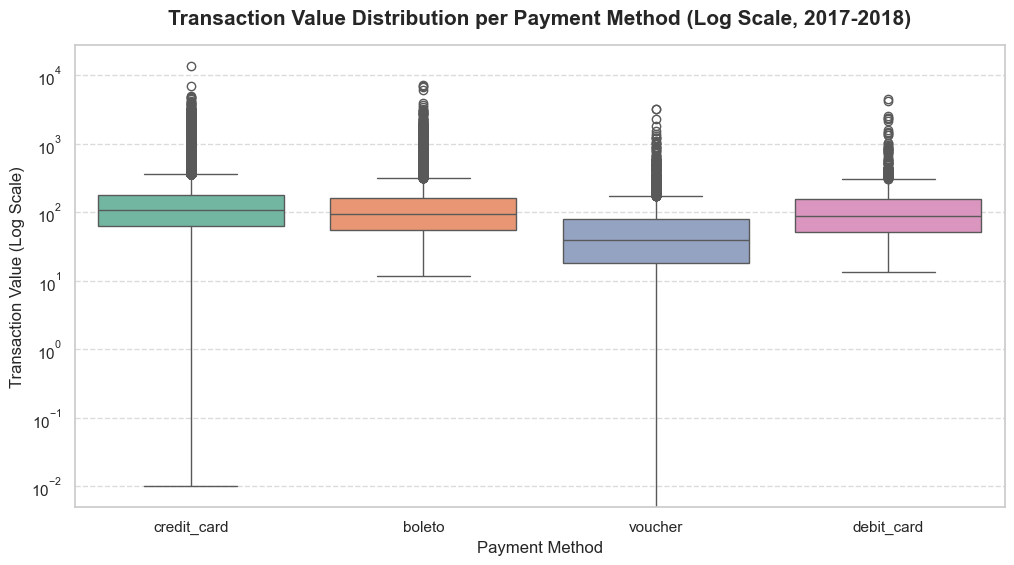

In [10]:
path_orders = f"dataset/olist_orders_dataset.csv"
df_orders = pd.read_csv(path_orders)

path_payments = f"{path}/olist_order_payments_dataset.csv"
df_payments = pd.read_csv(path_payments)

df_merged = pd.merge(df_payments, df_orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='inner')

df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

df_filtered = df_merged[df_merged['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()

df_filtered = df_filtered[df_filtered['payment_type'] != 'not_defined']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_filtered, x='payment_type', y='payment_value', estimator='mean', errorbar=None, palette='viridis')
plt.title('Average Transaction Value per Payment Method (2017-2018)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Average Transaction Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='payment_type', y='payment_value', palette='Set2')
plt.title('Transaction Value Distribution per Payment Method (Log Scale, 2017-2018)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Transaction Value (Log Scale)', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**

- Order volume starts increasing significantly from 07:00, reaching its first peak at 10:00–11:00 (6,500 orders).
- After a slight dip at 12:00 (likely due to lunch break), volume remains consistently high between 13:00–16:00.
- A second, lower peak occurs at 20:00–21:00, indicating nighttime shopping activity.
- The lowest volume is recorded at 04:00–05:00 in the early morning.
- From the heatmap, weekdays (Monday–Thursday) show the highest intensity between 10:00–18:00, while Friday remains active only until 17:00, suggesting customers begin disengaging ahead of the weekend.
- Saturday shows more evenly distributed but lower activity compared to weekdays.
- Interestingly, Sunday activity shifts toward the evening (18:00–22:00), diverging from the typical weekday pattern.

- Credit card has the highest average transaction value (163), followed by boleto (145) and debit card (142) which are relatively similar, while voucher is significantly lower (65), expected, as vouchers are typically used as partial discounts rather than full payment methods.
- From the log-scale boxplot, the median for credit card, boleto, and debit card sits around 100, while voucher falls around 40–50.
- All three main payment methods show high-value transaction outliers reaching up to 10,000, indicating the presence of high-value customer segments across all methods.
- Boleto has a notably long lower whisker (approaching 0.01), suggesting the existence of near-zero boleto transactions that may warrant investigation as anomalous data.
- Voucher shows the narrowest spread and consistently lowest values, reinforcing its role as a supplementary payment method rather than a primary one.

## Conclusion

- Peak order time occurs between 10:00–16:00 on weekdays (Monday–Thursday), with the highest peak at 10:00–11:00 reaching 6,500 orders. A smaller secondary peak appears at 20:00–21:00, reflecting nighttime shopping behavior. Sunday shows a distinct pattern, with activity shifting to the evening (18:00–22:00) rather than daytime as seen on weekdays. Overall, 10:00–16:00 on weekdays is the optimal window for promotions or operations requiring high traffic.
- Credit card is the payment method with the highest average transaction value, followed by boleto and debit card which are relatively equal in the range of 142–145. Voucher has the lowest average value as it is generally used as a supplementary method rather than a full payment. All primary payment methods show the presence of high-value customer segments with transactions reaching up to 10,000. Overall, credit card is not only the most popular payment method but also generates the highest transaction value, making it the most strategically significant method to optimize from a business perspective.

In [11]:
import shutil
shutil.make_archive("dataset", "zip", "dataset")

'c:\\Users\\LENOVO\\Documents\\BootcampCourse\\ecommerce-analysis-dashboard\\dataset.zip'